# LSE ST451: Bayesian Machine Learning
## Author: Kostas Kalogeropoulos

## Week 8: Markov Chain Monte Carlo / Bayesian Sparse Linear Regression

Topics covered 
 - Sampling from the posterior using the Gibbs Sampler in Python
 - Presenting the output of a Markov Chain Monte Carlo (MCMC) ouput 
 - Bayesian Sparse Linear Regression using *Spike and Slab priors*
 - Recommender systems via matrix factorisation

We will use standard Python libraries 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import time
%matplotlib inline
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from scipy.stats import norm

### Gibbs sampler

We will first code a Gibbs Sampler for the model where $y=(y_1,\dots,y_n)$ are independent $N(\mu,
\sigma^2)$ random variables with both $\mu$ and $\sigma^2$ unknown.

We will assign the $N(0,\omega^2)$ prior on $\mu$ and the $IGamma(\alpha,\beta)$ prior on $\sigma^2$.

Then we get that 

$$
\mu |y,\sigma^2 \sim N\left(\frac{\omega^2\bar{y}}{\omega^2 + \sigma^2/n},\frac{\omega^2 \sigma^2/n}{\omega^2 + \sigma^2/n}\right)
$$
and
$$
\sigma^2|y,\mu \sim IGamma (n/2+\alpha, \beta+\frac{\sum_{i=1}^{n}(y_i-\bar{y})^2+n(\bar{y}-\theta)^2}{2})
$$

#### First we simulate data

In [2]:
#Simulate data to check the Gibbs sampler
n = 100 #sample size
sigma_true = 2
sigma2_true = sigma_true**2
mu_true = 5
np.random.seed(4)
y = mu_true + np.random.randn(n)*sigma_true
ybar = np.mean(y)
S2 = np.sum((y-ybar)**2)
print('data:',y)
print('sample mean:',ybar)
print('sample variance:',S2/(n-1))

data: [5.10112341 5.99990267 3.00818214 6.38719702 4.16339696 1.83084553
 3.70458647 6.19715035 5.66450007 2.70504673 6.23733938 4.82402614
 5.85014479 5.66450629 2.68636748 5.70199431 3.78622543 8.09395866
 6.44668322 5.09227113 3.03401669 5.10886548 5.31978587 2.58210368
 9.44672043 5.78859043 8.38471543 2.77437569 8.27149508 2.27806882
 3.69754833 6.08490262 5.09601249 0.28385273 2.78883191 6.67567271
 9.17574174 6.82968192 4.44759329 6.5930238  2.71240286 6.01983957
 2.30507941 4.9812798  4.73859072 6.60417323 4.39407207 7.40400518
 4.60650944 6.6730574  6.57320457 1.31824827 5.07509497 5.0718561
 3.44252015 5.35882143 2.08893135 6.11237045 6.01955771 5.60089109
 9.95316832 5.70468679 5.134942   3.5354706  5.59428242 3.0764464
 7.54363723 3.70471093 5.31693907 8.98016603 7.32837512 5.48532032
 7.75984019 4.89088259 6.5904679  5.03817992 3.18912373 5.86054266
 6.86930013 4.30779626 2.80575623 3.94360786 0.24044945 3.78463262
 2.84941982 9.04481013 3.87024941 1.9141419  6.74168356 4.

#### Now we run the Gibbs sampler 

In [3]:
N = 10000 # number of iterations

#create object mus and sigma2s to store the Markov chain samples, 
#with $\pi(\theta,\sigma^2|y)$ as stationary distribution
out_mu = np.zeros(N)
out_sigma2 = np.zeros(N)

#Set prior parameters
omega2 = 1000
alpha = 0.1
beta = 0.1

#Set initial values for mu and sigma2
mu = 20
sigma2 = 10

for i in range(N):
    #Store current value of the chain (mu,sigma2)
    out_mu[i] = mu
    out_sigma2[i] = sigma2
    
    #Draw mu given y and sigma2
    denominator = omega2 + (sigma2/n)
    M = omega2*ybar/denominator          #Mean of the full conditional of mu
    V = omega2*(sigma2/n)/denominator    #Variance of the full conditional of mu 
    mu = M + np.sqrt(V)*np.random.randn(1)  #Draw from the full conditional of mu
    
    #Draw sigma2 given y and mu
    A = 0.5*n + alpha                  #A parameter of the full conditional of sigma2
    B = beta + 0.5*(S2+ n*((ybar-mu)**2)) #B parameter of the full conditional of sigma2
    sigma2 = 1/np.random.gamma(A, 1/B, 1)

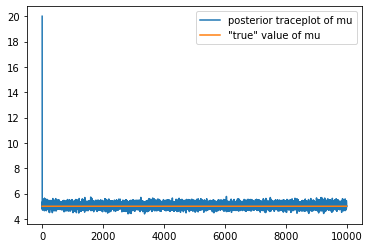

In [4]:
plt.plot(out_mu,label='posterior traceplot of mu')
plt.plot(np.ones(N)*mu_true,label='"true" value of mu')
plt.legend()
plt.show()

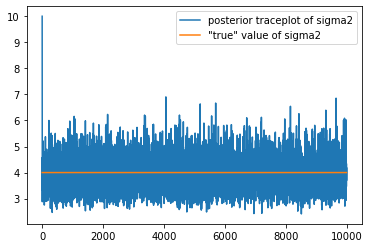

In [5]:
plt.plot(out_sigma2,label='posterior traceplot of sigma2')
plt.plot(np.ones(N)*sigma2_true,label='"true" value of sigma2')
plt.legend()
plt.show()

In [6]:
#present the output via a pandas data frame
mmu = np.mean(out_mu)
medmu = np.median(out_mu)
pctmu = np.percentile(out_mu,(2.5,97.5))
msig = np.mean(out_sigma2)
medsig = np.median(out_sigma2)
pctsig = np.percentile(out_sigma2,(2.5,97.5))
results = np.array([[mmu,medmu,pctmu[0],pctmu[1]],[msig,medsig,pctsig[0],pctsig[1]]]).round(3)
col = ['Posterior mean','Posterior median','Posterior 2.5% point','Posterior 97.5% point']
ind = ['mu','sigma2']
results = pd.DataFrame(results,columns = col,index=ind)
results

,Posterior mean,Posterior median,Posterior 2.5% point,Posterior 97.5% point
mu,5.070,5.069,4.685,5.448
sigma2,3.907,3.857,2.946,5.200


### Activity 1

Repeat for the model below

$$
y_i\sim \text{Poisson}(\mu), \;\;i=1,...,N,
$$
with priors 
$$
\mu \sim \text{Gamma}(2,\beta),\;\;
\beta \sim \text{Exponential}(1)
$$

It can be shown (good exercise) that the full conditionals for $\mu,\beta$ are 

$$
\mu| y,\beta \;\sim\;\text{Gamma}(2 + \sum_i y_i,n+\beta)
$$
$$
\beta|y,\mu\;\sim \;\text{Gamma}(3,1+\mu)
$$

Put your code below

In [22]:
#Simulate data to check the Gibbs sampler
n = 1000 #sample size
np.random.seed(4)

beta_true = np.random.exponential(1,1)
mu_true = np.random.gamma(2,1/beta_true,1)
ys = np.random.poisson(mu_true,n)

ybar = np.mean(ys)
print("Sample mean: ", ybar)
print("mu: ", mu_true)

Sample mean:  0.694
mu:  [0.67942744]


In [ ]:
N = 10000 # number of iterations

#create object mus and sigma2s to store the Markov chain samples, 
#with $\pi(\theta,\sigma^2|y)$ as stationary distribution
out_mu = np.zeros(N)
out_sigma2 = np.zeros(N)

#Set prior parameters


#Set initial values for mu and sigma2
mu = 4
beta = 10

for i in range(N):
    #Store current value of the chain (mu,sigma2)
    out_mu[i] = mu
    out_sigma2[i] = sigma2
    
    #Draw mu given y and sigma2
    denominator = omega2 + (sigma2/n)
    M = omega2*ybar/denominator          #Mean of the full conditional of mu
    V = omega2*(sigma2/n)/denominator    #Variance of the full conditional of mu 
    mu = M + np.sqrt(V)*np.random.randn(1)  #Draw from the full conditional of mu
    
    #Draw sigma2 given y and mu
    A = 0.5*n + alpha                  #A parameter of the full conditional of sigma2
    B = beta + 0.5*(S2+ n*((ybar-mu)**2)) #B parameter of the full conditional of sigma2
    sigma2 = 1/np.random.gamma(A, 1/B, 1)

### Bayesian Sparse Linear Regression

We will illustrate several Bayesian (or not) approaches to handle sparsity in linear regression on the diabetes dataset.

Some info on the data is given below:

 - 442 diabetes patients
 - 10 main variables, x_1,...,x_{10} : age, gender, body mass index, average blood pressure (map), and six blood serum measurements (tc, ldl, hdl, tch, ltg, glu)
 - 45 interactions of the form xjxk
 - 9 quadratic effects of the form x_j^2 (gender is binary, so x^2=x_2^2)
 - measure of disease progression taken one year later, $y$

We have a total of $p=64$ variables that we might use to predict $y$. It seems plausible that a subset of the variables will reliably predict $y$

First we load the `diabetes.data.txt` file to get y

In [24]:
diabetesY = pd.read_csv('diabetes.data.txt',sep="\t")
diabetesY.head()

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,59,2,32.1,101.0,157,93.2,38.0,4.0,4.8598,87,151
1,48,1,21.6,87.0,183,103.2,70.0,3.0,3.8918,69,75
2,72,2,30.5,93.0,156,93.6,41.0,4.0,4.6728,85,141
3,24,1,25.3,84.0,198,131.4,40.0,5.0,4.8903,89,206
4,50,1,23.0,101.0,192,125.4,52.0,4.0,4.2905,80,135


In [25]:
y = diabetesY['Y']
y = (y - np.mean(y))/np.std(y)
y.shape

(442,)

Then we load the `data64.txt` file to get X

In [26]:
diabetesX = pd.read_csv('data64.txt', sep="\t")
X = diabetesX.values
X = (X - np.mean(X,axis=0))/np.std(X,axis=0)
X.shape

(442, 64)

Split the data into train and test datasets.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=100/442, random_state=5)
X_test.shape

(100, 64)

A function to visualise the values of the coefficients

In [28]:
def plot_coefficients(coefficients, feature_names,num_features=64):
    plt.figure(figsize=(15,4))
    plt.bar(range(num_features), np.abs(coefficients))
    plt.xticks(range(num_features),feature_names[:num_features],rotation=-45)
    plt.xlabel('Feature')
    plt.ylabel('Absolute Value of Coefficients - log scale')
    plt.yscale('log')

Now we can start fitting models. We start with the **null model** (no covariates) and the **OLS** (all covariates)

null:  1.1065023419524171
OLS:  0.5751053849626849


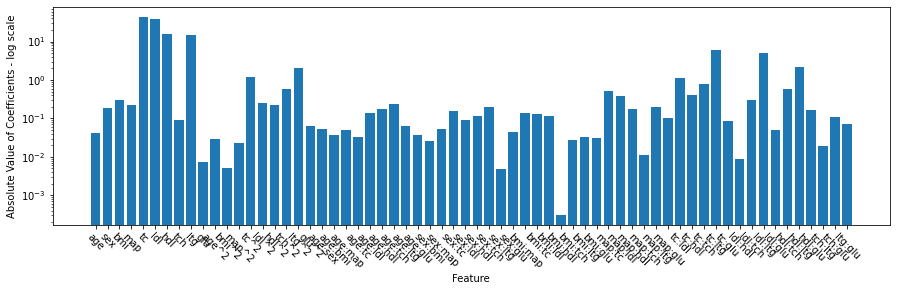

In [29]:
# Null model use the sample mean of y
print('null: ',np.sum((y_test - np.mean(y_train))**2) / len(y_test))

# OLS 
linreg = LinearRegression()
linreg.fit(X_train,y_train)
y_pred = linreg.predict(X_test)
print('OLS: ',np.sum((y_test - y_pred)**2) / len(y_test))
feature_names = diabetesX.columns.values
plot_coefficients(linreg.coef_,feature_names)
plt.show()

Next we apply **Ridge** and **Lasso** regression. For each of these, we search for the penalty parameter that minimises the MSE and report that.

Ridge:  0.5383388812798642  lambda:  21.5


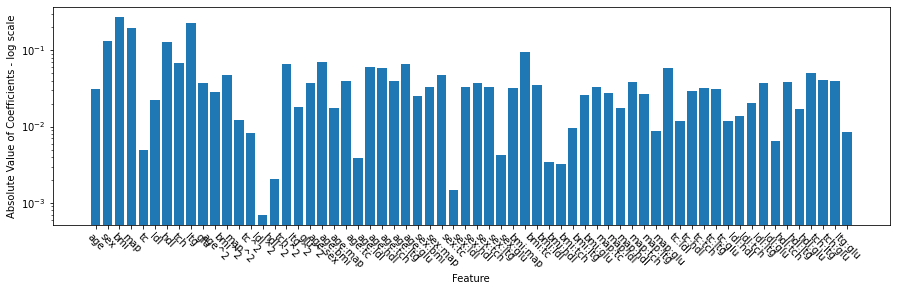

In [30]:
# Ridge
Lambdas = np.linspace(0.5,50,100)
MSEs = np.zeros(100)
for i in range(100):
    ridgereg = Ridge(alpha=Lambdas[i])
    ridgereg.fit(X_train,y_train)
    y_pred = ridgereg.predict(X_test)
    MSEs[i] = np.sum((y_test - y_pred)**2) / len(y_test)
print('Ridge: ',np.min(MSEs),' lambda: ',Lambdas[np.argmin(MSEs)])
plot_coefficients(ridgereg.coef_,feature_names)
plt.show()

Lasso:  0.5103975075352163  lambda:  0.04


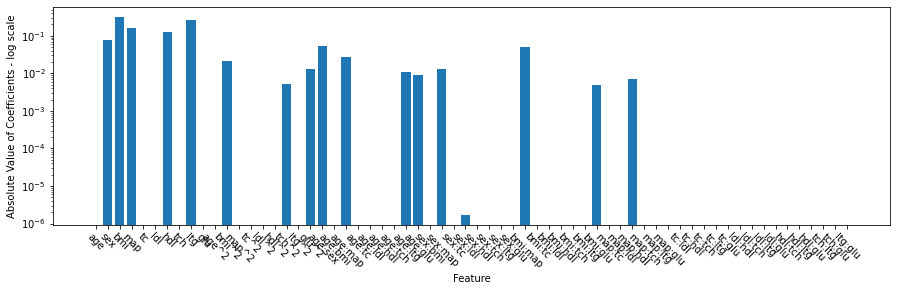

In [31]:
# Lasso
Lambdas = np.linspace(1e-2,1,100)
MSEs = np.zeros(100)
lassoreg = {}
for i in range(100):
    lassoreg[i] = Lasso(alpha=Lambdas[i])
    lassoreg[i].fit(X_train,y_train)
    y_pred = lassoreg[i].predict(X_test)
    MSEs[i] = np.sum((y_test - y_pred)**2) / len(y_test)
print('Lasso: ',np.min(MSEs),' lambda: ',Lambdas[np.argmin(MSEs)])
plot_coefficients(lassoreg[np.argmin(MSEs)].coef_,feature_names)
plt.show()

### Spike and Slab Priors in Linerar Regression

Let us return to the 'diabetes' dataset and apply the Spike and Slab Priors approach, i.e. the model below

$$
y\sim N\left|(X\beta, \sigma^2 I \right),
$$
$$
\beta_i \sim \gamma_i N(0,\psi^2) +(1-\gamma_i) N(0,\omega^2),\;\;\;\;\omega < < \psi
$$
$$
\gamma_i \sim\text{Bernoulli}(\pi_{\gamma})
$$

The Gibbs Sampler for this model is given next.

#### Gibbs Sampler for Spike and Slab Priors

For each $\beta_i$ denote with $p_{spike}^{(i)}$ the pdf of $N(\beta_i|0,r\psi^2)$ for a user specified small $r$, e.g. $10^{-4}$ and with $p_{slab}^{(i)}$ the pdf of $N(\beta_i|0,\psi^2)$. Then, the **full conditional posteriors** are:

 - $\gamma_i \sim Bernoulli(p_i)$, where $p_i=\left(1+\frac{(1-\pi_{\gamma})p_{spike}^{(i)}}{\pi_{\gamma}p_{slab}^{(i)}}\right)^{-1}$, $i=1,\dots,d$.
 - $\beta \sim N(b, B)$, where $B^{-1} = \frac{1}{\sigma^2}X^TX+D^{-1}$, $b=BX^Ty/\sigma^2$ and $D$ is a $d\times d$ diagonal matrix with entries equal to $\tau^2$ if $\gamma_i=1$ and $r\psi^2$ if $\gamma_i=0$.
 - $\sigma^2\sim IGamma((n-1)/2,S)$, where $n$ is the number of observations and $S=\frac{1}{2} (y-X\beta)^T(y-X\beta)$. 

Code a Gibbs sampler and run it on the diabetes data, setting $\psi=1$ and $\omega^2=r\psi^2=r$. Put your code below:

In [33]:
num_iterations = 10000 # number of iterations
d = X_train.shape[1] #number of dimensions|
N = len(y_train) #number of observations 

#create object mus and sigma2s to store the Markov chain samples, 
#with $\pi((beta, gamma, sigma^2)|y)$ as stationary distribution
out_sigma2 = np.zeros(num_iterations)
out_beta = np.zeros((num_iterations,d))
out_gamma = np.zeros((num_iterations,d))

#Set prior parameters
psi = np.ones(d)
r = 0.0001
pi_gamma = 0.5

#Set initial values 
mu = 0
sigma2 = 10
beta = np.zeros(d)
gamma = np.zeros(d)
np.random.seed(1)

for i in range(num_iterations):
    #Store current value of the chain (beta, gamma, sigma2)
    out_sigma2[i] = sigma2
    out_gamma[i,] = gamma
    out_beta[i,] = beta
    
    #step 1: Draw gamma
    p_spike = norm.pdf(beta, scale=np.sqrt(r * psi))
    p_slab  = norm.pdf(beta, scale=np.sqrt(psi))
    L = p_spike/p_slab
    ps = 1/(1+((1-pi_gamma)*L/pi_gamma) )
    gamma = np.random.binomial(1, p=ps)
    
    #step 2 draw beta
    r_gamma = 1 * gamma + r * (1 - gamma)
    D_inv = np.diag(1/(r_gamma * psi))
    B_N_inv = np.transpose(X_train).dot(X_train)/sigma2 + D_inv
    B_N = np.linalg.inv(B_N_inv)
    b_N = B_N.dot(np.transpose(X_train)).dot(y_train) / sigma2
    beta = np.random.multivariate_normal(b_N, B_N)
    
    #step 3 draw sigma2
    s_N = (N - 1)/2.    
    v = y_train - X_train.dot(beta)
    S_N = v.T.dot(v)/2
    sigma2 = 1/np.random.gamma(s_N,1/S_N)

MSE: 0.5060325274276849
[0.0379 0.954  0.9995 0.9972 0.2895 0.2372 0.7324 0.1749 0.9964 0.044
 0.0816 0.0964 0.0508 0.0714 0.0621 0.0932 0.1588 0.0766 0.1054 0.5906
 0.0545 0.1626 0.078  0.0749 0.0929 0.0759 0.1527 0.0911 0.1065 0.1151
 0.0704 0.0936 0.0813 0.1075 0.0442 0.0642 0.3727 0.063  0.0579 0.0657
 0.0784 0.0532 0.0867 0.0559 0.0604 0.0837 0.0526 0.0669 0.0531 0.0596
 0.0994 0.1716 0.0528 0.093  0.0979 0.1608 0.07   0.0889 0.1171 0.0888
 0.0609 0.1081 0.0829 0.055 ]


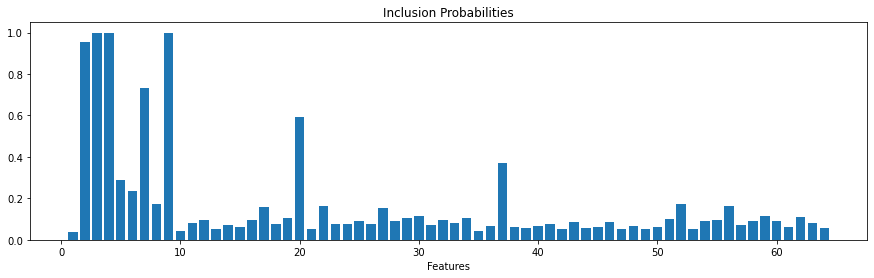

In [34]:
beta_hat=np.mean(out_beta,0)
y_pred = X_test.dot(beta_hat)
MSE = np.sum((y_test - y_pred)**2) / len(y_test)
print('MSE:', MSE)
inclusion_probs=np.mean(out_gamma,axis=0)
print(inclusion_probs)
features=np.linspace(1,d,d)
plt.figure(figsize=(15,4))
plt.bar(features,inclusion_probs)
plt.title('Inclusion Probabilities')
plt.xlabel('Features')
plt.show()

### Activity 2

Experiment with different values of pi_gamma

A pi_gamma=0.2 gives improved performance.

### Recommender systems via matrix factorisation with Gibbs sampling

Dataset: MovieLens 100k

Before running, make sure that the files u.data and u.item exist in the working directory

#### $\texttt{u.data}$
This is the ratings dataset, where each row represents one rating that a user gave to a movie. It contains four columns:
- $\texttt{user}$: user ID
- $\texttt{item}$: movie ID
- $\texttt{rating}$: rating score
- $\texttt{timestamp}$: rating timestamp

#### $\texttt{u.item}$
This is the movie information table. In this code, only the first two columns are read, so only the following variables are retained:
- $\texttt{item}$: movie ID
- $\texttt{title}$: movie title

1. Load MovieLens data

In [36]:
np.random.seed(123)


ratings_path = "u.data"
movies_path = "u.item"

ratings = pd.read_csv(
    ratings_path,
    sep="\t",
    names=["user", "item", "rating", "timestamp"]
)

movies = pd.read_csv(
    movies_path,
    sep="|",
    encoding="latin-1",
    header=None,
    usecols=[0, 1]
)
movies.columns = ["item", "title"]

print("Ratings:", ratings.shape)
print("Users:", ratings["user"].nunique())
print("Items:", ratings["item"].nunique())

FileNotFoundError: [Errno 2] No such file or directory: 'u.data'

In [ ]:
movies

In [ ]:
ratings

2. Build user-item matrix and choose small subset

We restrict attention to the first 150 users and the first 200 movies.

In [ ]:
n_users_full = int(ratings["user"].max())
n_items_full = int(ratings["item"].max())

R_all = np.full((n_users_full, n_items_full), np.nan)

for row in ratings.itertuples(index=False):
    R_all[row.user - 1, row.item - 1] = row.rating

# Small classroom subset
users_subset = 150
items_subset = 200

R = R_all[:users_subset, :items_subset]
mask = ~np.isnan(R)

# Keep only items with at least a few ratings
min_item_obs = 5
good_items = np.where(mask.sum(axis=0) >= min_item_obs)[0]
R = R[:, good_items]
mask = ~np.isnan(R)

item_id_map = good_items + 1
n_users, n_items = R.shape

print("\nSubset shape:", R.shape)
print("Observed ratings:", int(mask.sum()))
print("Observed fraction:", round(mask.mean(), 4))

3. Train/test split on observed entries

In [ ]:
observed_pairs = np.argwhere(mask)
perm = np.random.permutation(len(observed_pairs))
test_size = int(0.2 * len(observed_pairs))

test_idx = observed_pairs[:test_size]
train_idx = observed_pairs[test_size:]

train_mask = np.zeros_like(mask, dtype=bool)
test_mask = np.zeros_like(mask, dtype=bool)

train_mask[train_idx[:, 0], train_idx[:, 1]] = True
test_mask[test_idx[:, 0], test_idx[:, 1]] = True

mu = np.nanmean(R[train_mask])
R_train = np.where(train_mask, R, np.nan)

print("Training ratings:", int(train_mask.sum()))
print("Test ratings:", int(test_mask.sum()))

Our aim is to predict the many unobserved entries in the user--movie rating matrix, since in recommender systems most users rate only a small subset of movies. To achieve this, we introduce latent variables to capture unobserved user preferences and movie characteristics, which helps the model infer missing ratings from the observed sparse data.

### Model specification
For each observed rating $(i,j)\in\Omega$, we assume
$$
R_{ij} = \mu + a_i + b_j + u_i^\top v_j + \varepsilon_{ij},
\qquad
\varepsilon_{ij}\sim \mathcal{N}(0,\sigma^2),
$$
where $\mu$ is the global mean, $a_i$ is the user-specific bias, $b_j$ is the item-specific bias, and $u_i,v_j\in\mathbb{R}^K$ are the latent factors for user $i$ and item $j$, respectively. 

Intuitively, $u_i$ represents what user $i$ tends to like, and $v_j$ represents the hidden features of item $j$, so that $u_i^\top v_j$ reflects their degree of compatibility.

### Likelihood
Conditional on the parameters, the likelihood for the observed entries is
$$
p(R_{\Omega}\mid \mu,\mathbf a,\mathbf b,U,V,\sigma^2)
=
\prod_{(i,j)\in\Omega}
\mathcal{N}\!\bigl(R_{ij}\mid \mu+a_i+b_j+u_i^\top v_j,\sigma^2\bigr).
$$
Equivalently,
$$
p(R_{\Omega}\mid \mu,\mathbf a,\mathbf b,U,V,\sigma^2)
\propto
(\sigma^2)^{-|\Omega|/2}
\exp\!\left(
-\frac{1}{2\sigma^2}
\sum_{(i,j)\in\Omega}
\bigl(R_{ij}-\mu-a_i-b_j-u_i^\top v_j\bigr)^2
\right).
$$

### Prior distributions
Independent Gaussian priors are assigned as
$$
a_i \sim \mathcal{N}(0,\tau_a^2), \qquad
b_j \sim \mathcal{N}(0,\tau_b^2),
$$
$$
u_i \sim \mathcal{N}(0,\lambda_u^{-1}I_K), \qquad
v_j \sim \mathcal{N}(0,\lambda_v^{-1}I_K),
$$
for $i=1,\dots,n_{\mathrm{users}}$ and $j=1,\dots,n_{\mathrm{items}}$.

4. Model hyperparameters and index lists

In [ ]:
# ------------------------------------------------------------
# 4. Model hyperparameters
# ------------------------------------------------------------
K = 3
sigma2 = 0.5
lambda_u = 1.0
lambda_v = 1.0
a = np.zeros(n_users)   # user biases
b = np.zeros(n_items)   # item biases

tau_a2 = 1.0
tau_b2 = 1.0

print("\nHyperparameters:")
print("K =", K)
print("sigma2 =", sigma2)
print("lambda_u =", lambda_u)
print("lambda_v =", lambda_v)

# ------------------------------------------------------------
# Precompute index lists
# ------------------------------------------------------------
user_items = [np.where(train_mask[i, :])[0] for i in range(n_users)]
item_users = [np.where(train_mask[:, j])[0] for j in range(n_items)]

5. Helper functions

In [ ]:
def sample_user_bias(i, b, U, V, R_train, user_items, mu, sigma2, tau_a2):
    """
    Sample user bias a_i from its Gaussian full conditional.
    """
    items_i = user_items[i]

    if len(items_i) == 0:
        return np.random.normal(0.0, np.sqrt(tau_a2))

    resid = np.empty(len(items_i))
    for idx, j in enumerate(items_i):
        resid[idx] = R_train[i, j] - mu - b[j] - U[i, :].dot(V[j, :])

    post_var = 1.0 / (1.0 / tau_a2 + len(items_i) / sigma2)
    post_mean = post_var * resid.sum() / sigma2

    return np.random.normal(post_mean, np.sqrt(post_var))


def sample_item_bias(j, a, U, V, R_train, item_users, mu, sigma2, tau_b2):
    """
    Sample item/movie bias b_j from its Gaussian full conditional.
    """
    users_j = item_users[j]

    if len(users_j) == 0:
        return np.random.normal(0.0, np.sqrt(tau_b2))

    resid = np.empty(len(users_j))
    for idx, i in enumerate(users_j):
        resid[idx] = R_train[i, j] - mu - a[i] - U[i, :].dot(V[j, :])

    post_var = 1.0 / (1.0 / tau_b2 + len(users_j) / sigma2)
    post_mean = post_var * resid.sum() / sigma2

    return np.random.normal(post_mean, np.sqrt(post_var))


def sample_user_factor(i, a, b, V, R_train, user_items, mu, sigma2, lambda_u):
    """
    Sample user latent factor u_i from its Gaussian full conditional.
    """
    items_i = user_items[i]
    K = V.shape[1]

    if len(items_i) == 0:
        return np.random.multivariate_normal(np.zeros(K), np.eye(K) / lambda_u)

    V_i = V[items_i, :]
    r_tilde = np.empty(len(items_i))

    for idx, j in enumerate(items_i):
        r_tilde[idx] = R_train[i, j] - mu - a[i] - b[j]

    precision = lambda_u * np.eye(K) + (V_i.T @ V_i) / sigma2
    cov = np.linalg.inv(precision)
    mean = cov @ ((V_i.T @ r_tilde) / sigma2)

    return np.random.multivariate_normal(mean, cov)


def sample_item_factor(j, a, b, U, R_train, item_users, mu, sigma2, lambda_v):
    """
    Sample item/movie latent factor v_j from its Gaussian full conditional.
    """
    users_j = item_users[j]
    K = U.shape[1]

    if len(users_j) == 0:
        return np.random.multivariate_normal(np.zeros(K), np.eye(K) / lambda_v)

    U_j = U[users_j, :]
    r_tilde = np.empty(len(users_j))

    for idx, i in enumerate(users_j):
        r_tilde[idx] = R_train[i, j] - mu - a[i] - b[j]

    precision = lambda_v * np.eye(K) + (U_j.T @ U_j) / sigma2
    cov = np.linalg.inv(precision)
    mean = cov @ ((U_j.T @ r_tilde) / sigma2)

    return np.random.multivariate_normal(mean, cov)


def rmse(pred, truth, mask):
    return np.sqrt(np.mean((pred[mask] - truth[mask]) ** 2))

def movie_title_from_subset_col(subset_col_index, item_id_map, movies_df, max_len=30):
    original_item_id = int(item_id_map[subset_col_index])
    match = movies_df.loc[movies_df["item"] == original_item_id, "title"]

    if len(match) == 0:
        return f"Item {original_item_id}"

    title = match.iloc[0]

    # truncate long titles
    if len(title) > max_len:
        title = title[:max_len] + "..."

    return title

6. Run Gibbs Sample

In [ ]:
U = np.random.normal(0, 0.5, size=(n_users, K))
V = np.random.normal(0, 0.5, size=(n_items, K))

n_iter = 500
burn_in = 100

train_rmse_trace = []
test_rmse_trace = []

R_pred_sum = np.zeros((n_users, n_items))
saved_draws = 0

print("\nRunning Gibbs sampler...")
t0 = time.time()

for it in range(n_iter):
    # update user biases
    for i in range(n_users):
        a[i] = sample_user_bias(i, b, U, V, R_train, user_items, mu, sigma2, tau_a2)
    # update item biases
    for j in range(n_items):
        b[j] = sample_item_bias(j, a, U, V, R_train, item_users, mu, sigma2, tau_b2)

    # update user factors
    for i in range(n_users):
        U[i, :] = sample_user_factor(i, a, b, V, R_train, user_items, mu, sigma2, lambda_u)

    # update item factors
    for j in range(n_items):
        V[j, :] = sample_item_factor(j, a, b, U, R_train, item_users, mu, sigma2, lambda_v)

    R_hat = mu + a[:, None] + b[None, :] + U @ V.T

    train_rmse_trace.append(rmse(R_hat, R, train_mask))
    test_rmse_trace.append(rmse(R_hat, R, test_mask))

    if it >= burn_in:
        R_pred_sum += R_hat
        saved_draws += 1

    #print(f"Iter {it+1:2d}: train RMSE = {train_rmse_trace[-1]:.4f}, "
    #      f"test RMSE = {test_rmse_trace[-1]:.4f}")

R_pred_post = R_pred_sum / saved_draws
R_pred_post = np.clip(R_pred_post, 1, 5)

elapsed = time.time() - t0

print(f"\nElapsed time: {elapsed:.2f} seconds")

7. Results

In [ ]:
print("\nPosterior mean performance:")
print("Train RMSE:", round(rmse(R_pred_post, R, train_mask), 4))
print("Test RMSE: ", round(rmse(R_pred_post, R, test_mask), 4))

plt.figure(figsize=(7, 4))
plt.plot(train_rmse_trace, label="Train RMSE")
plt.plot(test_rmse_trace, label="Test RMSE")
plt.xlabel("Iteration")
plt.ylabel("RMSE")
plt.title("Gibbs sampler monitoring")
plt.legend()
plt.tight_layout()
plt.show()

The figure shows the training and test RMSE over Gibbs sampling iterations. The training RMSE quickly stabilises at a low level, whereas the test RMSE remains higher and more variable, suggesting weaker out-of-sample performance.

8. Inspect a few held-out predictions


In [ ]:
test_pairs = np.argwhere(test_mask)

rows_to_show = []
for idx in range(min(10, len(test_pairs))):
    i, j = test_pairs[idx]
    rows_to_show.append({
        "user": i + 1,
        "movie": movie_title_from_subset_col(j, item_id_map, movies),
        "true_rating": float(R[i, j]),
        "predicted_rating": float(R_pred_post[i, j]),
    })

results_df = pd.DataFrame(rows_to_show)
print("\nA few held-out predictions:")
print(results_df.round(3))

This table shows a few held-out test cases, comparing the true ratings with the ratings predicted by the model. It provides an illustrative check of how well the matrix factorisation model predicts unseen user--movie preferences.

---
This code displays the top recommended movies for a selected user among unrated items, together with some movies that the same user has already rated highly, in order to provide an intuitive check of recommendation quality.
- What movies does the recommender system most want to suggest to this user?
- Do these recommendations resemble the movies that this user genuinely liked before?

In [ ]:
# ------------------------------------------------------------
# Display: top 5 recommendations for one user
# and some movies that the same user already liked
# ------------------------------------------------------------

# Choose a user (Python index: 0 means MovieLens user 1)
user_id = 4
top_k = 5

# Predicted ratings matrix should already exist:
# R_pred_post

# mask indicates which entries are observed in the subset
# R contains the actual observed ratings where available

# 1. Top recommendations among movies the user has NOT rated
unrated_items = np.where(~mask[user_id])[0]
pred_scores = R_pred_post[user_id, unrated_items]

top_idx = np.argsort(pred_scores)[-top_k:][::-1]
recommended_items = unrated_items[top_idx]

recommended_rows = []
for j in recommended_items:
    recommended_rows.append({
        "movie": movie_title_from_subset_col(j, item_id_map, movies, max_len=35),
        "predicted_rating": R_pred_post[user_id, j]
    })

recommended_df = pd.DataFrame(recommended_rows)

print(f"Top {top_k} recommendations for user {user_id + 1}:")
print(recommended_df.round(3))

# 2. Movies this user already rated highly
rated_items = np.where(mask[user_id])[0]
liked_items = rated_items[R[user_id, rated_items] >= 4]

liked_rows = []
for j in liked_items:
    liked_rows.append({
        "movie": movie_title_from_subset_col(j, item_id_map, movies, max_len=35),
        "observed_rating": R[user_id, j],
        "predicted_rating": R_pred_post[user_id, j]
    })

liked_df = pd.DataFrame(liked_rows)

# Sort by observed rating first, then predicted rating
if len(liked_df) > 0:
    liked_df = liked_df.sort_values(
        by=["observed_rating", "predicted_rating"],
        ascending=[False, False]
    ).head(top_k)

print(f"\nSome movies already liked by user {user_id + 1}:")
print(liked_df.round(3))

### Activity 3

Change the latent dimension K, which denotes the number of factors.

    - How does test RMSE change?
    - How does runtime change?
    - Do the recommendations look different?
